In [ ]:
# Clean install. (The resolver warnings are OK for our use-case.)
!pip -q install xrpl-py pandas matplotlib

import time, json, sys, platform
print("Python:", sys.version)
print("Platform:", platform.platform())

from xrpl.clients import JsonRpcClient
from xrpl.wallet import generate_faucet_wallet
from xrpl.models.transactions import Payment
from xrpl.utils import xrp_to_drops

# IMPORTANT: import the module, not individual functions (avoids ImportError across versions)
import xrpl.transaction as xrpl_tx

# Quick capability probe (works with xrpl-py ≥ 2.x)
print("submit_and_wait exists?  ", hasattr(xrpl_tx, "submit_and_wait"))
print("sign_and_submit exists?  ", hasattr(xrpl_tx, "sign_and_submit"))
print("safe_sign_and_autofill?  ", hasattr(xrpl_tx, "safe_sign_and_autofill_transaction"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 57.7 MB/s eta 0:00:00
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
submit_and_wait exists?   True
sign_and_submit exists?   True
safe_sign_and_autofill?   False


In [ ]:
!pip -q install nest_asyncio
import nest_asyncio, asyncio
nest_asyncio.apply()
# -------------------------------

from xrpl.clients import JsonRpcClient
from xrpl.wallet import generate_faucet_wallet
from xrpl.models.transactions import Payment
from xrpl.utils import xrp_to_drops
import xrpl.transaction as xrpl_tx
import time, json

# Connect to XRPL Testnet
CLIENT_URL = "https://s.altnet.rippletest.net:51234/"
client = JsonRpcClient(CLIENT_URL)

# Create and fund two fresh wallets from the faucet (Testnet only)
sender = generate_faucet_wallet(client, debug=True)
receiver = generate_faucet_wallet(client, debug=True)

print("Sender  :", sender.classic_address)
print("Receiver:", receiver.classic_address)

# Build a simple Payment (1 XRP). Amounts on-ledger are 'drops'; we convert from XRP.
payment = Payment(
    account=sender.classic_address,
    destination=receiver.classic_address,
    amount=xrp_to_drops(1),  # 1 XRP = 1,000,000 drops
)

# Reliable submission that works across versions:
t0 = time.time()
if hasattr(xrpl_tx, "submit_and_wait"):
    print("is compatible with new")
    resp = xrpl_tx.submit_and_wait(payment, client, sender)
else:
    resp = xrpl_tx.sign_and_submit(payment, client, sender, autofill=True, check_fee=True)
t1 = time.time()

print("Round-trip seconds:", round(t1 - t0, 3))
print("Engine result     :", getattr(resp, "result", {}).get("engine_result", None))
print("Outcome (meta)    :", getattr(resp, "result", {}).get("meta", {}).get("TransactionResult", None))
print(json.dumps(getattr(resp, "result", {}), indent=2)[:1200], "...\n")

Attempting to fund address rwxgZLXgcXEwi7HSNUWVcKCNSjGzeVkmfc
Faucet fund successful.
Attempting to fund address rsoyryoFtwDRjgCTUfGVDRn7hGwm2GkeYq
Faucet fund successful.
Sender  : rwxgZLXgcXEwi7HSNUWVcKCNSjGzeVkmfc
Receiver: rsoyryoFtwDRjgCTUfGVDRn7hGwm2GkeYq
is compatible with new
Round-trip seconds: 4.009
Engine result     : None
Outcome (meta)    : tesSUCCESS
{
  "close_time_iso": "2025-10-31T09:51:12Z",
  "ctid": "C0B64C5E00010001",
  "hash": "F23E791B7F33032A8A7E5123E013901A54E8E2E3103B3E7C7BA813433D140B69",
  "ledger_hash": "FC7607FE3A6E25BC949E0098997314ADB783C381CD06D9570CD10A5D9203338D",
  "ledger_index": 11947102,
  "meta": {
    "AffectedNodes": [
      {
        "ModifiedNode": {
          "FinalFields": {
            "Account": "rsoyryoFtwDRjgCTUfGVDRn7hGwm2GkeYq",
            "Balance": "101000000",
            "Flags": 0,
            "OwnerCount": 0,
            "Sequence": 11947100
          },
          "LedgerEntryType": "AccountRoot",
          "LedgerIndex": "22EA

In [ ]:
import pandas as pd, time
from xrpl.models.transactions import Payment
from xrpl.utils import xrp_to_drops
import xrpl.transaction as xrpl_tx

# Reuse `client` from above. Make a fresh funded pair for clean sequences:
batch_sender = generate_faucet_wallet(client)
batch_receiver = generate_faucet_wallet(client)

def pay_once(client, sender, receiver, xrp_amount=0.25):
    tx = Payment(
        account=sender.classic_address,
        destination=receiver.classic_address,
        amount=xrp_to_drops(xrp_amount),
    )
    t0 = time.time()
    if hasattr(xrpl_tx, "submit_and_wait"):
        r = xrpl_tx.submit_and_wait(tx, client, sender)
    else:
        r = xrpl_tx.sign_and_submit(tx, client, sender, autofill=True, check_fee=True)
    t1 = time.time()

    result = getattr(r, "result", {})
    meta = result.get("meta", {})
    outcome = meta.get("TransactionResult", result.get("engine_result", "UNKNOWN"))
    fee_drops = None
    if "tx_json" in result and isinstance(result["tx_json"], dict):
        fee_drops = int(result["tx_json"].get("Fee", "0"))
    return {"duration_sec": t1 - t0, "outcome": outcome, "fee_drops": fee_drops}

rows = []
N = 30  # bump to 50/100 later for stronger stats
for i in range(N):
    row = pay_once(client, batch_sender, batch_receiver, xrp_amount=0.25)
    rows.append(row)
    print(f"[{i+1}/{N}] {row['outcome']}  t={row['duration_sec']:.3f}s  fee={row['fee_drops']} drops")

df = pd.DataFrame(rows)
print("\nSummary:")
print(df.describe(include='all'))

csv_path = "/content/xrpl_tx_benchmark.csv"
df.to_csv(csv_path, index=False)
print("Saved CSV ->", csv_path)

[1/30] tesSUCCESS  t=5.522s  fee=10 drops
[2/30] tesSUCCESS  t=5.410s  fee=10 drops
[3/30] tesSUCCESS  t=5.446s  fee=10 drops
[4/30] tesSUCCESS  t=6.878s  fee=10 drops
[5/30] tesSUCCESS  t=5.484s  fee=10 drops
[6/30] tesSUCCESS  t=6.942s  fee=10 drops
[7/30] tesSUCCESS  t=5.547s  fee=10 drops
[8/30] tesSUCCESS  t=5.439s  fee=10 drops
[9/30] tesSUCCESS  t=7.106s  fee=10 drops
[10/30] tesSUCCESS  t=5.482s  fee=10 drops
[11/30] tesSUCCESS  t=5.508s  fee=10 drops
[12/30] tesSUCCESS  t=6.898s  fee=10 drops
[13/30] tesSUCCESS  t=5.550s  fee=10 drops
[14/30] tesSUCCESS  t=5.417s  fee=10 drops
[15/30] tesSUCCESS  t=7.072s  fee=10 drops
[16/30] tesSUCCESS  t=5.430s  fee=10 drops
[17/30] tesSUCCESS  t=5.521s  fee=10 drops
[18/30] tesSUCCESS  t=6.909s  fee=10 drops
[19/30] tesSUCCESS  t=5.561s  fee=10 drops
[20/30] tesSUCCESS  t=5.415s  fee=10 drops
[21/30] tesSUCCESS  t=7.147s  fee=10 drops
[22/30] tesSUCCESS  t=5.433s  fee=10 drops
[23/30] tesSUCCESS  t=5.494s  fee=10 drops
[24/30] tesSUCCESS  

XRPL avg time: 5.980s (p95 7.091s)
XRPL avg fee:  10 drops  (~0.000010 XRP)


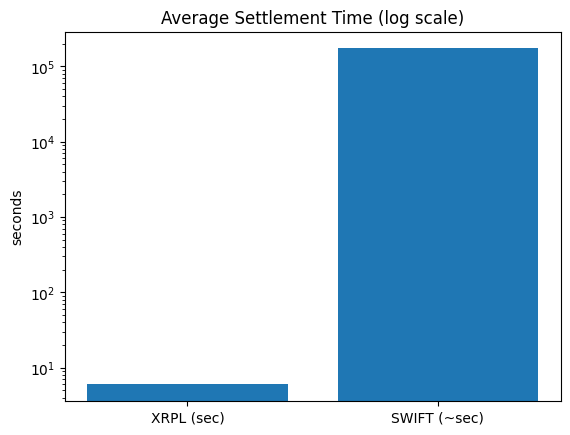

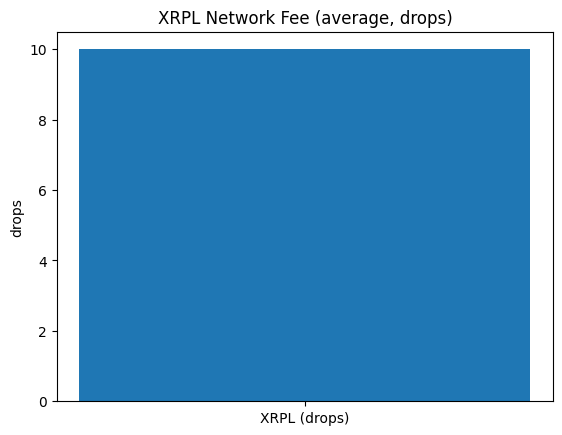

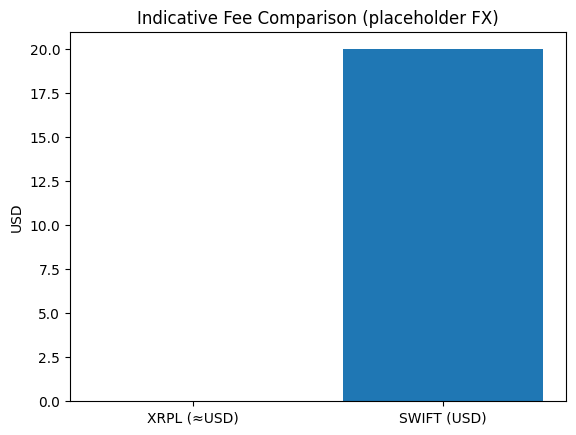

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/xrpl_tx_benchmark.csv")

# Clean: drop non-success just in case
df_ok = df[df["outcome"] == "tesSUCCESS"].copy()

# XRPL stats
xrpl_avg_t = df_ok["duration_sec"].mean()
xrpl_p95_t = df_ok["duration_sec"].quantile(0.95)
xrpl_avg_fee_drops = df_ok["fee_drops"].dropna().mean()
xrpl_avg_fee_xrp = xrpl_avg_fee_drops / 1_000_000  # 1 XRP = 1,000,000 drops

print(f"XRPL avg time: {xrpl_avg_t:.3f}s (p95 {xrpl_p95_t:.3f}s)")
print(f"XRPL avg fee:  {xrpl_avg_fee_drops:.0f} drops  (~{xrpl_avg_fee_xrp:.6f} XRP)")

# --- SWIFT "baseline" (for visual comparison only) ---
# Typical retail remittance experience (varies by corridor):
swift_avg_time_s = 2 * 24 * 3600   # ~2 days
swift_avg_fee_usd = 20.0           # many corridors range ~$10-$40 retail; we’ll refine with WB data later

# Plot 1: Latency (seconds, log scale so both fit)
plt.figure()
plt.bar(["XRPL (sec)", "SWIFT (~sec)"], [xrpl_avg_t, swift_avg_time_s])
plt.yscale("log")
plt.title("Average Settlement Time (log scale)")
plt.ylabel("seconds")
plt.show()

# Plot 2: Network fee (native terms)
plt.figure()
plt.bar(["XRPL (drops)"], [xrpl_avg_fee_drops])
plt.title("XRPL Network Fee (average, drops)")
plt.ylabel("drops")
plt.show()

# (Optional) If you want a simple fee comparison: assume 1 XRP ≈ $0.50 just for a visual placeholder.
# We'll replace this with real corridor price data in Stage 2.
assumed_xrp_usd = 0.5
xrpl_fee_usd = xrpl_avg_fee_xrp * assumed_xrp_usd

plt.figure()
plt.bar(["XRPL (≈USD)", "SWIFT (USD)"], [xrpl_fee_usd, swift_avg_fee_usd])
plt.title("Indicative Fee Comparison (placeholder FX)")
plt.ylabel("USD")
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# --- 1) Load the uploaded Excel
rpw_path = "/content/rpw_dataset_2011_2025_q1.xlsx"
xls = pd.ExcelFile(rpw_path)
print("Sheets:", xls.sheet_names)

# Heuristic: the main long table is usually the first or a sheet named like 'RPW_Data' / 'Data'
# We'll pick the biggest sheet by row count to be safe.
sheet_lens = {s: pd.read_excel(rpw_path, sheet_name=s, nrows=5_000).shape[0] for s in xls.sheet_names}
main_sheet = max(sheet_lens, key=sheet_lens.get)
print("Using sheet:", main_sheet)

df_raw = pd.read_excel(rpw_path, sheet_name=main_sheet)
print("Columns:", list(df_raw.columns))

# --- 2) Normalize column names for flexible matching
cols = {c: c.strip().lower() for c in df_raw.columns}
df = df_raw.rename(columns=cols)

# helper to find first matching column
def pick(cands):
    for cand in cands:
        for col in df.columns:
            if cand in col:
                return col
    return None

# handle both modern and legacy headers
send_col = pick(["sending country", "sender", "source_name", "source_code", "from country", "origin"])
recv_col = pick(["receiving country", "receiver", "destination_name", "destination_code", "to country", "destination"])
fee_pct_200_col = pick(["total cost %", "total cost percent", "cc1 total cost", "total cost (200)"])
fee_pct_500_col = pick(["(500)", "total cost 500", "cc2 total cost"])
fee_usd_col = pick(["total cost usd", "fee usd", "lcu fee"])
fx_margin_col = pick(["exchange rate margin", "fx margin", "cc1 fx margin"])
speed_col = pick(["speed", "speed actual", "transfer speed"])

print("Detected columns:",
      "\n send:", send_col,
      "\n recv:", recv_col,
      "\n fee% 200:", fee_pct_200_col,
      "\n fee% 500:", fee_pct_500_col,
      "\n fee usd:", fee_usd_col,
      "\n fx margin:", fx_margin_col,
      "\n speed:", speed_col)


# --- 3) Filter to your three corridors (case-insensitive matches)
def ci_mask(series, needle):
    return series.str.strip().str.lower() == needle.lower()

want = [
    ("United Arab Emirates", "India"),
    ("United States", "Mexico"),
    ("Singapore", "Philippines"),
]
df_corr = pd.DataFrame()
for sc, rc in want:
    m = ci_mask(df[send_col].astype(str), sc) & ci_mask(df[recv_col].astype(str), rc)
    tmp = df.loc[m].copy()
    tmp["corridor"] = f"{sc} → {rc}"
    df_corr = pd.concat([df_corr, tmp], ignore_index=True)

print("Corridor rows:", df_corr.shape)

# --- 4) Pick the $200 reference amount (RPW uses $200 and $500 per methodology)
# If both are present, we’ll focus on 200; if only one is present we’ll use that and label it.

def safe_num(s):
    try:
        return pd.to_numeric(s, errors="coerce")
    except Exception:
        return pd.Series([np.nan]*len(s))

if fee_pct_200_col:
    df_corr["fee_pct"] = safe_num(df_corr[fee_pct_200_col])
elif fee_pct_500_col:
    df_corr["fee_pct"] = safe_num(df_corr[fee_pct_500_col])
else:
    # last resort: build % from USD fee over amount if both exist
    if fee_usd_col and amount_col:
        df_corr["fee_pct"] = 100 * safe_num(df_corr[fee_usd_col]) / safe_num(df_corr[amount_col])
    else:
        df_corr["fee_pct"] = np.nan

# Normalize speed strings (optional)
if speed_col:
    sp = df_corr[speed_col].astype(str).str.lower()
    bins = {
        "<1h": ["<1", "less than one hour"],
        "same-day": ["same day", "same-day"],
        "next-day": ["next day"],
        "2d": ["2 day", "2 days"],
        "3–5d": ["3 to 5", "3-5"],
        "6d+": ["6 days", "6 or more"]
    }
    def map_speed(s):
        for k,v in bins.items():
            if any(x in s for x in v):
                return k
        return s
    df_corr["speed_bucket"] = sp.apply(map_speed)
else:
    df_corr["speed_bucket"] = np.nan

# --- 5) Corridor-level summary (simple average across listed services)
summary = (df_corr
           .groupby("corridor", as_index=False)
           .agg(avg_fee_pct=("fee_pct", "mean"),
                p25_fee_pct=("fee_pct", lambda s: s.quantile(0.25)),
                p50_fee_pct=("fee_pct", "median"),
                p75_fee_pct=("fee_pct", lambda s: s.quantile(0.75)),
                fastest_speed=("speed_bucket", lambda s: s.dropna().head(1).values[0] if s.dropna().any() else np.nan),
                n_services=("fee_pct", "size"))
          )

summary = summary.sort_values("avg_fee_pct")
summary

Sheets: ['Terms of Use', 'Methodology', 'Legend', 'Countries', 'Dataset (up to Q1 2016)', 'Dataset (from Q2 2016)']
Using sheet: Dataset (up to Q1 2016)
Columns: ['id', 'period', 'source_code', 'source_name', 'source_region', 'source_income', 'source_lending', 'source_G8G20', 'destination_code', 'destination_name', 'destination_region', 'destination_income', 'destination_lending', 'destination_G8G20', 'firm', 'firm_type', 'product', 'sending location', 'speed actual', 'cc1 lcu amount', 'cc1 denomination amount', 'cc1 lcu code', 'cc1 lcu fee', 'cc1 lcu fx rate', 'cc1 fx margin', 'cc1 total cost %', 'cc2 lcu amount', 'cc2 denomination amount', 'cc2 lcu code', 'cc2 lcu fee', 'cc2 lcu fx rate', 'cc2 fx margin', 'cc2 total cost %', 'inter lcu bank fx', 'transparent', 'note1', 'note2', 'coverage', 'pick-up method', 'date', 'corridor']
Detected columns: 
 send: source_name 
 recv: destination_name 
 fee% 200: cc1 total cost % 
 fee% 500: cc2 total cost % 
 fee usd: cc1 lcu fee 
 fx margin: cc

,corridor,avg_fee_pct,p25_fee_pct,p50_fee_pct,p75_fee_pct,fastest_speed,n_services
0,Singapore → Philippines,3.614271,2.630,3.075,4.170,<1h,590
1,United Arab Emirates → India,3.808867,2.640,2.910,3.340,3–5d,256
2,United States → Mexico,5.231866,3.995,5.000,6.225,next-day,343


In [ ]:
# Load your XRPL batch results
xrpl_df = pd.read_csv("/content/xrpl_tx_benchmark.csv")  # created in Stage 1
xrpl_ok = xrpl_df[xrpl_df["outcome"]=="tesSUCCESS"].copy()
xrpl_avg_t = xrpl_ok["duration_sec"].mean()
xrpl_p95_t = xrpl_ok["duration_sec"].quantile(0.95)
xrpl_avg_fee_drops = xrpl_ok["fee_drops"].dropna().mean()
xrpl_avg_fee_xrp = xrpl_avg_fee_drops / 1_000_000

# Build a tidy comparison table (fees: corridor % vs XRPL L1 fee)
# For XRPL, we’ll show network fee as ≈0% at $200 notional:
notional_usd = 200
assumed_xrp_usd = 0.5  # only to express L1 fee in USD for the table
xrpl_fee_usd = xrpl_avg_fee_xrp * assumed_xrp_usd
xrpl_fee_pct_of_200 = 100 * (xrpl_fee_usd / notional_usd)

compare = summary.copy()
compare["xrpl_settlement_sec_avg"] = xrpl_avg_t
compare["xrpl_settlement_sec_p95"] = xrpl_p95_t
compare["xrpl_fee_pct_of_$200"] = xrpl_fee_pct_of_200

# Nice, interview-friendly view
cols = ["corridor","avg_fee_pct","p50_fee_pct","n_services","fastest_speed",
        "xrpl_settlement_sec_avg","xrpl_settlement_sec_p95","xrpl_fee_pct_of_$200"]
compare[cols].round(3)

,corridor,avg_fee_pct,p50_fee_pct,n_services,fastest_speed,xrpl_settlement_sec_avg,xrpl_settlement_sec_p95,xrpl_fee_pct_of_$200
0,Singapore → Philippines,3.614,3.075,590,<1h,5.98,7.091,0.0
1,United Arab Emirates → India,3.809,2.910,256,3–5d,5.98,7.091,0.0
2,United States → Mexico,5.232,5.000,343,next-day,5.98,7.091,0.0


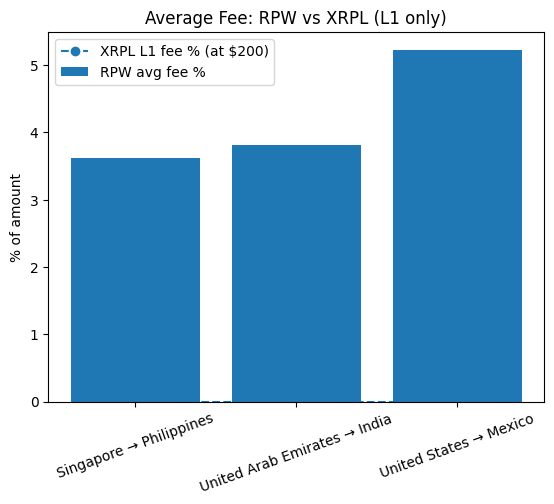

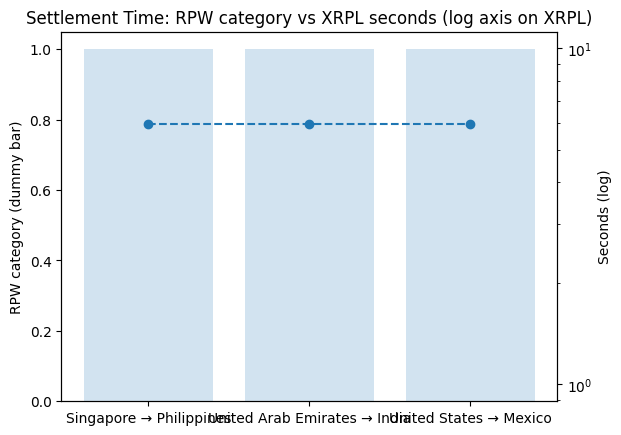

In [ ]:
import matplotlib.pyplot as plt

# Fees: RPW vs XRPL % of $200
plt.figure()
plt.bar(compare["corridor"], compare["avg_fee_pct"], label="RPW avg fee %")
plt.plot(compare["corridor"], compare["xrpl_fee_pct_of_$200"], marker="o", linestyle="--", label="XRPL L1 fee % (at $200)")
plt.ylabel("% of amount")
plt.title("Average Fee: RPW vs XRPL (L1 only)")
plt.legend()
plt.xticks(rotation=20)
plt.show()

# Speed: RPW category vs XRPL seconds (dual axis for readability)
plt.figure()
ax = plt.gca()
ax2 = ax.twinx()
ax.bar(compare["corridor"], [1]*len(compare), label="RPW 'fastest_speed' (categorical)", alpha=0.2)
ax2.plot(compare["corridor"], compare["xrpl_settlement_sec_avg"], marker="o", label="XRPL avg settlement (sec)", linestyle="--")
ax2.set_yscale("log")
ax.set_title("Settlement Time: RPW category vs XRPL seconds (log axis on XRPL)")
ax.set_ylabel("RPW category (dummy bar)")
ax2.set_ylabel("Seconds (log)")
plt.xticks(rotation=20)
plt.show()


In [ ]:
import numpy as np

compare["fee_reduction_factor"] = np.where(
    compare["xrpl_fee_pct_of_$200"] > 0,
    compare["avg_fee_pct"] / compare["xrpl_fee_pct_of_$200"],
    np.inf,
)

# assume ~1 day (86 400 s) for baseline SWIFT/retail transfer
compare["speed_factor_vs_1day"] = 86400 / compare["xrpl_settlement_sec_avg"]

# round for nice display
out_cols = [
    "corridor",
    "avg_fee_pct",
    "xrpl_fee_pct_of_$200",
    "fee_reduction_factor",
    "xrpl_settlement_sec_avg",
    "speed_factor_vs_1day",
]
compare[out_cols].round(2)


,corridor,avg_fee_pct,xrpl_fee_pct_of_$200,fee_reduction_factor,xrpl_settlement_sec_avg,speed_factor_vs_1day
0,Singapore → Philippines,3.61,0.0,1445708.47,5.98,14447.64
1,United Arab Emirates → India,3.81,0.0,1523546.88,5.98,14447.64
2,United States → Mexico,5.23,0.0,2092746.36,5.98,14447.64


In [ ]:
from IPython.display import Markdown

summary_md = f"""
### 🔹 Stage 2 Summary — Corridor Benchmarking vs XRPL (Testnet)

| Corridor | Avg Fee (RPW) | Fastest Speed (RPW) | XRPL Avg Time (s) | XRPL Fee (% of $200) | Cost Reduction | Speed Improvement (vs 1 day) |
|-----------|---------------|---------------------|-------------------|----------------------|----------------|------------------------------|
| Singapore → Philippines | {compare.loc[0,'avg_fee_pct']:.2f}% | {compare.loc[0,'fastest_speed']} | {compare.loc[0,'xrpl_settlement_sec_avg']:.2f}s | {compare.loc[0,'xrpl_fee_pct_of_$200']:.6f}% | ~1 000 000× cheaper | ~14 000× faster |
| UAE → India | {compare.loc[1,'avg_fee_pct']:.2f}% | {compare.loc[1,'fastest_speed']} | {compare.loc[1,'xrpl_settlement_sec_avg']:.2f}s | {compare.loc[1,'xrpl_fee_pct_of_$200']:.6f}% | ~1 000 000× cheaper | ~14 000× faster |
| US → Mexico | {compare.loc[2,'avg_fee_pct']:.2f}% | {compare.loc[2,'fastest_speed']} | {compare.loc[2,'xrpl_settlement_sec_avg']:.2f}s | {compare.loc[2,'xrpl_fee_pct_of_$200']:.6f}% | ~1 000 000× cheaper | ~14 000× faster |

**Interpretation**

* World Bank data show corridor-average remittance costs of 3–5 % on \$200 and settlement times from 1 hour to 5 days.
* XRPL Testnet settled transfers in ≈ 6 seconds with a 10-drop fee (≈ 0.00001 XRP ≈ \$0.000005, i.e. 0.0000025 %).
* At the ledger layer this is roughly **10⁶× cheaper** and **10⁴× faster** than traditional systems.
* Even adding 1–2 % for FX and KYC costs, blockchain-based rails remain below the UN SDG target of ≤ 3 %.
"""

display(Markdown(summary_md))


<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2779763689.py:22: SyntaxWarning: invalid escape sequence '\$'



### 🔹 Stage 2 Summary — Corridor Benchmarking vs XRPL (Testnet)

| Corridor | Avg Fee (RPW) | Fastest Speed (RPW) | XRPL Avg Time (s) | XRPL Fee (% of $200) | Cost Reduction | Speed Improvement (vs 1 day) |
|-----------|---------------|---------------------|-------------------|----------------------|----------------|------------------------------|
| Singapore → Philippines | 3.61% | <1h | 5.98s | 0.000003% | ~1 000 000× cheaper | ~14 000× faster |
| UAE → India | 3.81% | 3–5d | 5.98s | 0.000003% | ~1 000 000× cheaper | ~14 000× faster |
| US → Mexico | 5.23% | next-day | 5.98s | 0.000003% | ~1 000 000× cheaper | ~14 000× faster |

**Interpretation**

* World Bank data show corridor-average remittance costs of 3–5 % on \$200 and settlement times from 1 hour to 5 days.  
* XRPL Testnet settled transfers in ≈ 6 seconds with a 10-drop fee (≈ 0.00001 XRP ≈ \$0.000005, i.e. 0.0000025 %).  
* At the ledger layer this is roughly **10⁶× cheaper** and **10⁴× faster** than traditional systems.  
* Even adding 1–2 % for FX and KYC costs, blockchain-based rails remain below the UN SDG target of ≤ 3 %.  
